# In-Domain Handcrafted Linguistic Feature Stability Analysis (CCC)

Within each grouped stratified fold, highly correlated predictors were first removed using Pearson pruning (|r| > .70). L1-regularized logistic regression was then applied for sparse feature selection and in-domain diagnosis classification. Only non-zero coefficients were treated as selected features for stability analysis.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

In [2]:
DATA_PATH = "/Users/gloria/Documents/uniproject/thesis/outputs/ccc_extractedfeatures.csv"
OUTPUT_DIR = "/Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output"
VIZ_DIR = "/Users/gloria/Documents/uniproject/thesis/visualizations/in_domain_feature_stability_visualizations"

df = pd.read_csv(DATA_PATH)

EXCLUDE_COLS = ["id", "individual", "aggregated_utterances"]
TARGET = "diagnosis"

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS + [TARGET]]

X = df[feature_cols].copy()
X = X.select_dtypes(include=[np.number]).copy()
feature_cols = list(X.columns)
y = df[TARGET].values
groups = df["individual"].values

print(f"Total candidate predictors before pruning: {len(feature_cols)}")
print(f"Dataset shape: {df.shape}")
print(f"Unique participants: {df['individual'].nunique()}")

Total candidate predictors before pruning: 46
Dataset shape: (290, 50)
Unique participants: 83


## Constant Feature Removal

Constant features are removed because Pearson correlation is undefined for variables with zero variance. This is a data-cleaning step, not an additional feature-selection method.

In [3]:
# Drop constant numeric features (std = 0) before correlation and pruning
os.makedirs(OUTPUT_DIR, exist_ok=True)

constant_features = list(X.columns[X.std() == 0])
X = X.loc[:, X.std() > 0]
feature_cols = list(X.columns)

print(f"Constant features removed: {len(constant_features)}")
if constant_features:
    for f in constant_features:
        print(f"  - {f}")
else:
    print("  (none)")
print(f"Feature count after constant removal: {len(feature_cols)}")

pd.DataFrame({"constant_feature": constant_features}).to_csv(
    os.path.join(OUTPUT_DIR, "ccc_constant_features_removed.csv"), index=False
)
print(f"Saved: {OUTPUT_DIR}/ccc_constant_features_removed.csv")

Constant features removed: 0
  (none)
Feature count after constant removal: 46
Saved: /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_constant_features_removed.csv


In [4]:
def pearson_prune(X_train, threshold=0.70):
    """Upper-triangle deterministic Pearson correlation pruning.
    Returns retained feature list and list of (kept, dropped, correlation) tuples."""
    corr = X_train.corr(method="pearson").abs()
    cols = list(X_train.columns)
    to_drop = set()
    dropped_pairs = []
    for i in range(len(cols)):
        if cols[i] in to_drop:
            continue
        for j in range(i + 1, len(cols)):
            if cols[j] in to_drop:
                continue
            r = corr.loc[cols[i], cols[j]]
            if r > threshold:
                to_drop.add(cols[j])
                dropped_pairs.append((cols[i], cols[j], round(float(r), 4)))
    retained = [c for c in cols if c not in to_drop]
    return retained, dropped_pairs

In [5]:
# STEP 1: Global Pearson pruning (before CV loop)
retained, dropped_pairs_global = pearson_prune(X, threshold=0.70)
X_pruned = X[retained]
print(f"Pearson pruning: {len(feature_cols)} → {len(retained)} features retained")
for kept, dropped, r in dropped_pairs_global:
    print(f"  dropped '{dropped}' (r={r} with '{kept}')")

# STEP 2: CV loop
splitter = StratifiedGroupKFold(n_splits=5)

all_fold_coefficients = []
all_fold_performance = []

for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(X_pruned, y, groups), start=1):
    X_train = X_pruned.iloc[train_idx]
    y_train = y[train_idx]
    X_test  = X_pruned.iloc[test_idx]
    y_test  = y[test_idx]

    # Scale — fit on train only, transform both
    # fillna(0): zero-variance features in a fold produce NaN after scaling
    scaler = StandardScaler()
    X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=retained).fillna(0)
    X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=retained).fillna(0)

    # L1 logistic regression
    lr = LogisticRegression(penalty="l1", solver="liblinear", class_weight="balanced",
                            max_iter=5000, C=1.0)
    lr.fit(X_train_s, y_train)

    # Store only non-zero coefficients
    coef_series = pd.Series(lr.coef_[0], index=retained)
    nonzero_coefs = coef_series[coef_series != 0]
    print(f"Fold {fold_idx}: {len(nonzero_coefs)} non-zero L1-selected features")

    for feat, coef in nonzero_coefs.items():
        all_fold_coefficients.append({
            "fold": fold_idx,
            "feature": feat,
            "coefficient": coef,
            "abs_coefficient": abs(coef),
            "direction": "positive" if coef > 0 else "negative",
        })

    # Evaluation on held-out test fold
    y_pred = lr.predict(X_test_s)
    y_prob = lr.predict_proba(X_test_s)[:, 1]
    all_fold_performance.append({
        "fold": fold_idx,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "auc":       roc_auc_score(y_test, y_prob),
    })

fold_coef_df = pd.DataFrame(all_fold_coefficients)
dropped_pairs_df = pd.DataFrame([
    {"kept_feature": k, "dropped_feature": d, "correlation": r}
    for k, d, r in dropped_pairs_global
])
fold_perf_df = pd.DataFrame(all_fold_performance)

avg_perf = fold_perf_df.drop(columns="fold").mean()
std_perf = fold_perf_df.drop(columns="fold").std()

print(f"\nTotal foldwise coefficient rows (non-zero only): {len(fold_coef_df)}")
print(f"Total dropped pairs recorded: {len(dropped_pairs_df)}")
print(f"\nIn-domain performance (mean ± std across 5 folds):")
for m in ["accuracy", "precision", "recall", "f1", "auc"]:
    print(f"  {m:10s}: {avg_perf[m]:.3f} ± {std_perf[m]:.3f}")

fold_coef_df.head()

Pearson pruning: 46 → 31 features retained
  dropped 'n_polysyllables' (r=0.7743 with 'avg_word_length')
  dropped 'n_monosyllables' (r=0.8491 with 'avg_word_length')
  dropped 'ttr' (r=0.9945 with 'n_lemmas')
  dropped 'n_low_concreteness' (r=0.8636 with 'n_lemmas')
  dropped 'n_low_aoa' (r=0.9793 with 'n_lemmas')
  dropped 'n_part' (r=0.7081 with 'n_lemmas')
  dropped 'tree_depth' (r=0.9373 with 'tokens_per_sentence')
  dropped 'avg_Haptic_sensorimotor' (r=0.7077 with 'avg_concreteness')
  dropped 'avg_Visual_sensorimotor' (r=0.8141 with 'avg_concreteness')
  dropped 'avg_Olfactory_sensorimotor' (r=0.8925 with 'avg_Gustatory_sensorimotor')
  dropped 'avg_Torso_sensorimotor' (r=0.8034 with 'avg_Foot_leg_sensorimotor')
  dropped 'pronoun_noun_ratio' (r=0.8686 with 'n_noun')
  dropped 'verb_noun_ratio' (r=0.853 with 'n_noun')
  dropped 'noun_verb_ratio' (r=0.8475 with 'n_noun')
  dropped 'filler_to_noun_ratio' (r=0.9018 with 'n_intj')
Fold 1: 27 non-zero L1-selected features
Fold 2: 25 

/Users/gloria/Library/Caches/pypoetry/virtualenvs/thesis-r9vtuxML-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/gloria/Library/Caches/pypoetry/virtualenvs/thesis-r9vtuxML-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/gloria/Library/Caches/pypoetry/virtualenvs/thesis-r9vtuxML-py3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to 

,fold,feature,coefficient,abs_coefficient,direction
0,1,avg_word_length,0.518251,0.518251,positive
1,1,n_lemmas,-0.441029,0.441029,negative
2,1,tokens_per_sentence,-0.367691,0.367691,negative
3,1,avg_concreteness,0.060902,0.060902,positive
4,1,n_low_synsets,0.384310,0.384310,positive


## Pearson Correlation Analysis (Pre-Pruning)

Pearson correlation measures the strength and direction of the **linear relationship** between pairs of features. Values range from −1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear association.

Highly correlated features (|r| > 0.70) are likely to carry **redundant information**: including both in a model can inflate variance and reduce interpretability without improving predictive power. The heatmap below shows the signed correlation structure of the full feature set before any pruning, using a diverging colormap centred at 0 (red = positive correlation, blue = negative correlation).

The table of highly correlated pairs (|r| > 0.70) identifies candidates for removal; the subsequent Pearson pruning step uses absolute correlations to deterministically drop one feature from each such pair.

Saved: /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_pearson_correlation_matrix.csv


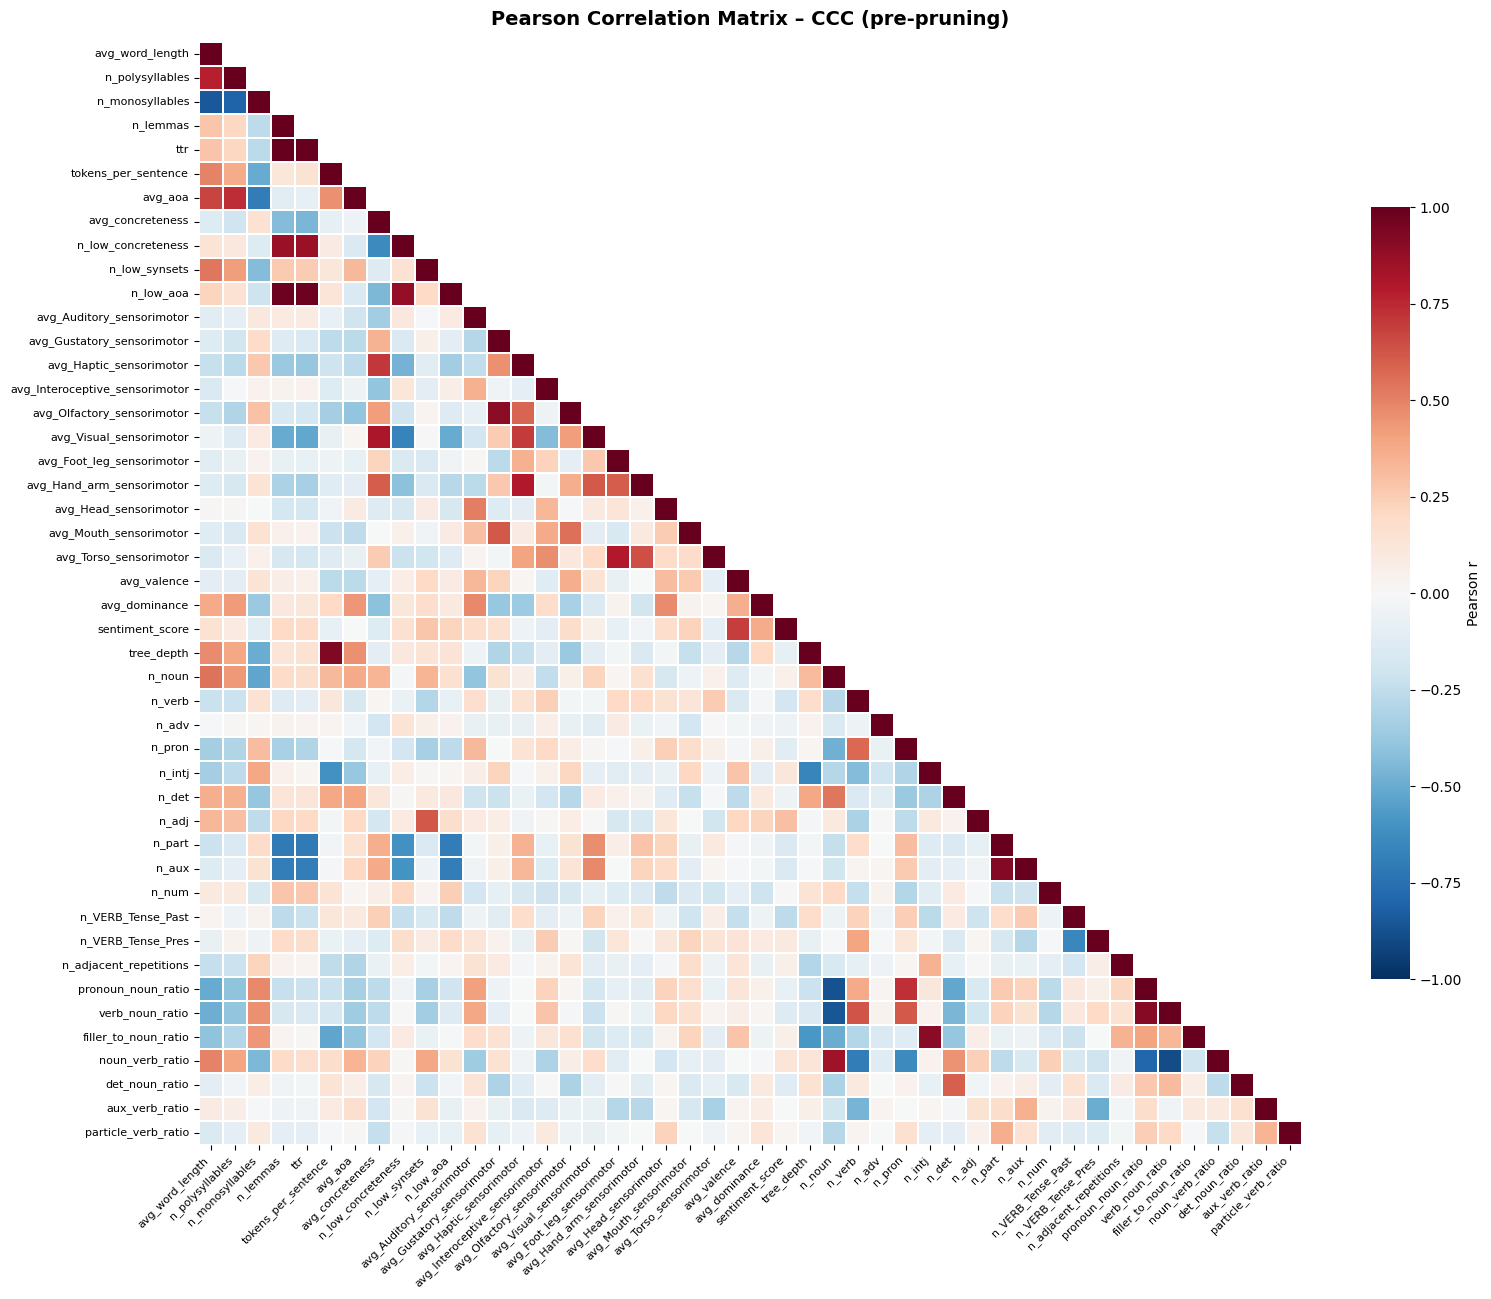

Saved: /Users/gloria/Documents/uniproject/thesis/visualizations/in_domain_feature_stability_visualizations/ccc_pearson_correlation_heatmap.png
Saved: /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_highly_correlated_pairs.csv
Highly correlated pairs (|r| > 0.70): 30


,feature_1,feature_2,pearson_correlation,abs_correlation
0,n_lemmas,ttr,0.9945,0.9945
1,n_lemmas,n_low_aoa,0.9793,0.9793
2,ttr,n_low_aoa,0.9770,0.9770
3,tokens_per_sentence,tree_depth,0.9373,0.9373
4,n_part,n_aux,0.9167,0.9167
5,pronoun_noun_ratio,verb_noun_ratio,0.9077,0.9077
6,n_intj,filler_to_noun_ratio,0.9018,0.9018
7,avg_Gustatory_sensorimotor,avg_Olfactory_sensorimotor,0.8925,0.8925
8,verb_noun_ratio,noun_verb_ratio,-0.8922,0.8922
9,n_low_concreteness,n_low_aoa,0.8809,0.8809


In [6]:
# ── Pearson Correlation Heatmap (pre-pruning, signed) ─────────────────────────
# Signed Pearson correlation matrix on the cleaned numeric feature matrix (after constant removal)
corr_signed = X.corr(method="pearson")

# Save signed correlation matrix as CSV
corr_signed.to_csv(os.path.join(OUTPUT_DIR, "ccc_pearson_correlation_matrix.csv"))
print(f"Saved: {OUTPUT_DIR}/ccc_pearson_correlation_matrix.csv")

# Heatmap: lower-triangle mask with k=1 so diagonal is visible
mask = np.triu(np.ones_like(corr_signed, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_signed,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    annot=False,
    linewidths=0.3,
    square=True,
    cbar_kws={"label": "Pearson r", "shrink": 0.7},
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix – CCC (pre-pruning)", fontsize=14, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "ccc_pearson_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {VIZ_DIR}/ccc_pearson_correlation_heatmap.png")

# Highly correlated feature pairs using absolute correlation (threshold > 0.70)
cols = list(corr_signed.columns)
high_corr_rows = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_signed.loc[cols[i], cols[j]]
        r_abs = abs(r)
        if r_abs > 0.70:
            high_corr_rows.append({
                "feature_1": cols[i],
                "feature_2": cols[j],
                "pearson_correlation": round(float(r), 4),
                "abs_correlation": round(float(r_abs), 4),
            })
high_corr_df = (
    pd.DataFrame(high_corr_rows)
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)
high_corr_df.to_csv(os.path.join(OUTPUT_DIR, "ccc_highly_correlated_pairs.csv"), index=False)
print(f"Saved: {OUTPUT_DIR}/ccc_highly_correlated_pairs.csv")
print(f"Highly correlated pairs (|r| > 0.70): {len(high_corr_df)}")
high_corr_df

In [7]:
# Aggregated feature stability summary
summary_rows = []

for feat in fold_coef_df["feature"].unique():
    feat_df = fold_coef_df[fold_coef_df["feature"] == feat]
    selected_folds = len(feat_df)
    avg_coef = feat_df["coefficient"].mean()
    avg_abs_coef = feat_df["abs_coefficient"].mean()
    directions = list(feat_df["direction"])
    stable_direction = len(set(directions)) == 1
    majority_direction = feat_df["direction"].mode()[0]
    summary_rows.append({
        "feature": feat,
        "selected_folds": selected_folds,
        "avg_coefficient": avg_coef,
        "avg_abs_coefficient": avg_abs_coef,
        "directions": directions,
        "stable_direction": stable_direction,
        "majority_direction": majority_direction,
        "stable": stable_direction and selected_folds >= 3,
    })

stability_summary = pd.DataFrame(summary_rows)
print(f"Features in stability summary: {len(stability_summary)}")
print(f"Stable-direction features: {stability_summary['stable_direction'].sum()}")
print(f"Stable features (direction + ≥3 folds): {stability_summary['stable'].sum()}")
stability_summary.head(10)

Features in stability summary: 30
Stable-direction features: 22
Stable features (direction + ≥3 folds): 20


,feature,selected_folds,avg_coefficient,avg_abs_coefficient,directions,stable_direction,majority_direction,stable
0,avg_word_length,4,0.476865,0.476865,"[positive, positive, positive, positive]",True,positive,True
1,n_lemmas,4,-0.300360,0.356142,"[negative, negative, positive, negative]",False,negative,False
2,tokens_per_sentence,4,-0.067802,0.222400,"[negative, negative, positive, negative]",False,negative,False
3,avg_concreteness,5,0.370170,0.370170,"[positive, positive, positive, positive, posit...",True,positive,True
4,n_low_synsets,5,0.324093,0.324093,"[positive, positive, positive, positive, posit...",True,positive,True
5,avg_Auditory_sensorimotor,5,0.934000,0.934000,"[positive, positive, positive, positive, posit...",True,positive,True
6,avg_Gustatory_sensorimotor,5,1.234648,1.234648,"[positive, positive, positive, positive, posit...",True,positive,True
7,avg_Foot_leg_sensorimotor,2,-0.141312,0.141312,"[negative, negative]",True,negative,False
8,avg_Hand_arm_sensorimotor,5,-0.085597,0.103722,"[positive, negative, negative, positive, negat...",False,negative,False
9,avg_Head_sensorimotor,5,0.224551,0.224551,"[positive, positive, positive, positive, posit...",True,positive,True


In [8]:
# Final ranking: stable features only (consistent direction + selected in ≥3 folds)
stable_ranked_features = (
    stability_summary[stability_summary["stable"]]
    .sort_values(["selected_folds", "avg_abs_coefficient"], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"Stable ranked features: {len(stable_ranked_features)}")
print("\nTop 15 final stable ranked features:")
print(stable_ranked_features[["feature", "selected_folds", "avg_abs_coefficient", "majority_direction"]].head(15).to_string(index=False))

Stable ranked features: 20

Top 15 final stable ranked features:
                   feature  selected_folds  avg_abs_coefficient majority_direction
avg_Gustatory_sensorimotor               5             1.234648           positive
               avg_valence               5             0.990600           positive
 avg_Auditory_sensorimotor               5             0.934000           positive
    avg_Mouth_sensorimotor               5             0.855973           negative
                     n_aux               5             0.833827           positive
       particle_verb_ratio               5             0.660328           positive
                     n_adv               5             0.634584           positive
                    n_intj               5             0.536566           positive
                    n_noun               5             0.498246           negative
                     n_det               5             0.477435           negative
             avg_domin

In [9]:
# Save CSV outputs
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

fold_coef_df.to_csv(os.path.join(OUTPUT_DIR, "ccc_fold_coefficients.csv"), index=False)
stability_summary.to_csv(os.path.join(OUTPUT_DIR, "ccc_feature_stability_summary.csv"), index=False)
stable_ranked_features.to_csv(os.path.join(OUTPUT_DIR, "ccc_stable_ranked_features.csv"), index=False)
dropped_pairs_df.to_csv(os.path.join(OUTPUT_DIR, "ccc_correlation_dropped_pairs.csv"), index=False)

fold_perf_df.to_csv(os.path.join(OUTPUT_DIR, "ccc_fold_performance_metrics.csv"), index=False)

avg_perf_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "auc"],
    "mean":   [avg_perf[m] for m in ["accuracy", "precision", "recall", "f1", "auc"]],
    "std":    [std_perf[m] for m in ["accuracy", "precision", "recall", "f1", "auc"]],
})
avg_perf_df.to_csv(os.path.join(OUTPUT_DIR, "ccc_average_performance_metrics.csv"), index=False)

print("Saved:")
print(f"  {OUTPUT_DIR}/ccc_fold_coefficients.csv")
print(f"  {OUTPUT_DIR}/ccc_feature_stability_summary.csv")
print(f"  {OUTPUT_DIR}/ccc_stable_ranked_features.csv")
print(f"  {OUTPUT_DIR}/ccc_correlation_dropped_pairs.csv")
print(f"  {OUTPUT_DIR}/ccc_fold_performance_metrics.csv")
print(f"  {OUTPUT_DIR}/ccc_average_performance_metrics.csv")

Saved:
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_fold_coefficients.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_feature_stability_summary.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_stable_ranked_features.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_correlation_dropped_pairs.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_fold_performance_metrics.csv
  /Users/gloria/Documents/uniproject/thesis/outputs/in_domain_feature_stability_output/ccc_average_performance_metrics.csv


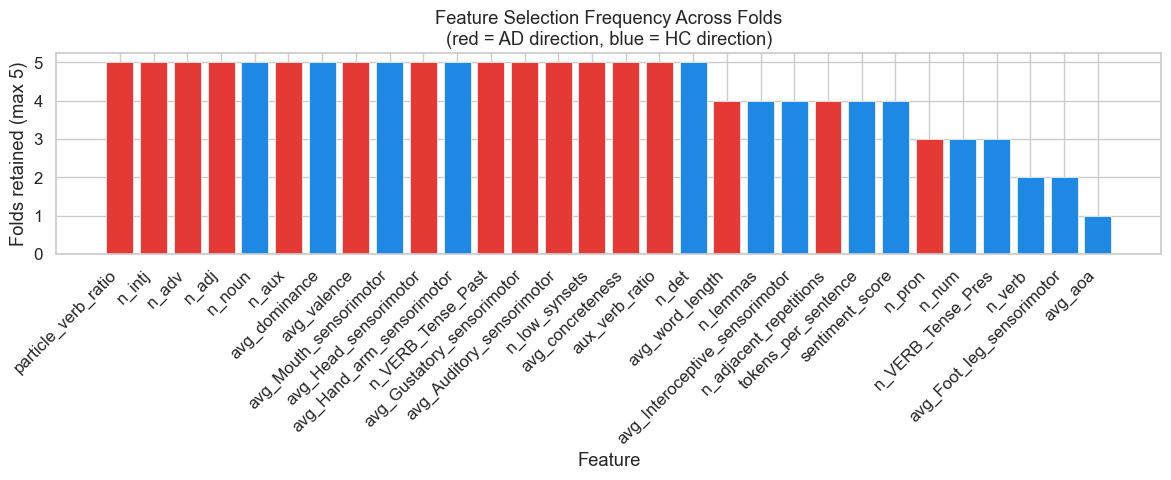

Saved: ccc_feature_selection_frequency.png


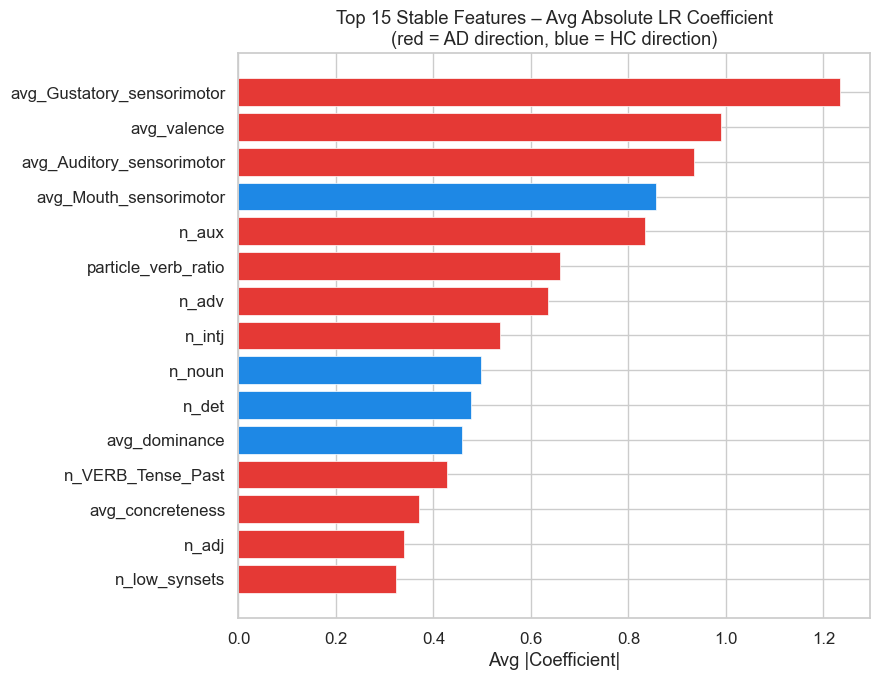

Saved: ccc_stable_features_coefficients.png


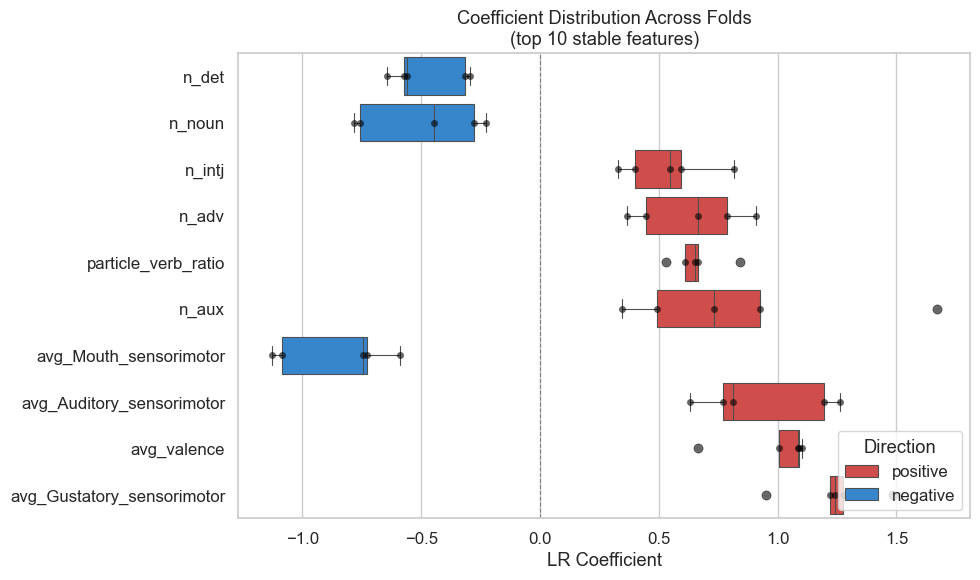

Saved: ccc_coefficient_distribution.png


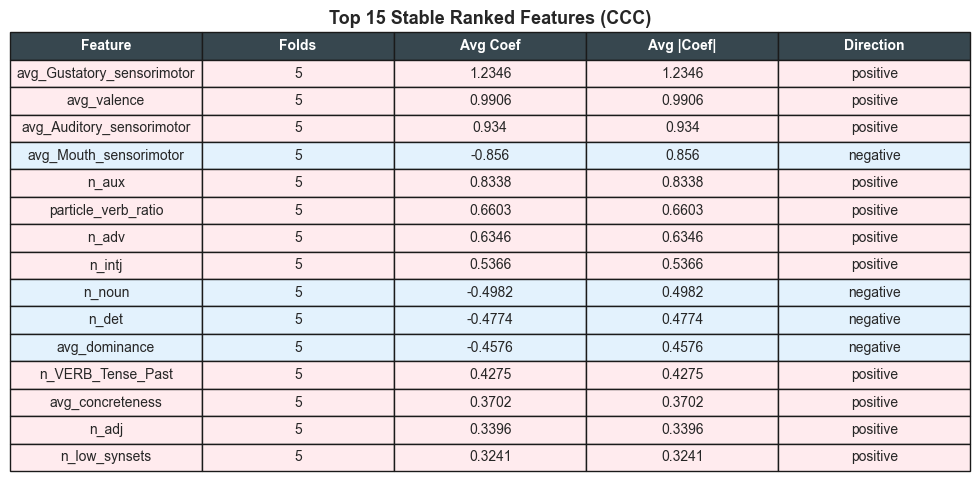

Saved: ccc_stable_ranked_table.png


In [10]:
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {"positive": "#E53935", "negative": "#1E88E5"}  # red = AD (1), blue = HC (0)

# ── 1. Feature selection frequency across folds ───────────────────────────────
freq = (
    stability_summary[["feature", "selected_folds"]]
    .sort_values("selected_folds", ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 5))
colors = [PALETTE[d] for d in stability_summary.set_index("feature").loc[freq["feature"], "majority_direction"]]
ax.bar(freq["feature"], freq["selected_folds"], color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Feature")
ax.set_ylabel("Folds retained (max 5)")
ax.set_title("Feature Selection Frequency Across Folds\n(red = AD direction, blue = HC direction)")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "ccc_feature_selection_frequency.png"), dpi=150)
plt.show()
print("Saved: ccc_feature_selection_frequency.png")

# ── 2. Stable features ranked by avg absolute coefficient ─────────────────────
top = stable_ranked_features.head(15).iloc[::-1]  # reverse for horizontal bar
fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = [PALETTE[d] for d in top["majority_direction"]]
ax.barh(top["feature"], top["avg_abs_coefficient"], color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Avg |Coefficient|")
ax.set_title("Top 15 Stable Features – Avg Absolute LR Coefficient\n(red = AD direction, blue = HC direction)")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "ccc_stable_features_coefficients.png"), dpi=150)
plt.show()
print("Saved: ccc_stable_features_coefficients.png")

# ── 3. Coefficient distribution across folds (top 10 stable features) ─────────
top10 = stable_ranked_features["feature"].head(10).tolist()
plot_df = fold_coef_df[fold_coef_df["feature"].isin(top10)].copy()
plot_df["feature"] = pd.Categorical(plot_df["feature"], categories=top10[::-1], ordered=True)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=plot_df, y="feature", x="coefficient",
    palette={"positive": "#E53935", "negative": "#1E88E5"},
    hue="direction", dodge=False, ax=ax, linewidth=0.8,
)
sns.stripplot(
    data=plot_df, y="feature", x="coefficient",
    color="black", size=5, alpha=0.6, jitter=False, ax=ax,
)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("LR Coefficient")
ax.set_ylabel("")
ax.set_title("Coefficient Distribution Across Folds\n(top 10 stable features)")
ax.legend(title="Direction", loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "ccc_coefficient_distribution.png"), dpi=150)
plt.show()
print("Saved: ccc_coefficient_distribution.png")

# ── 4. Top-15 stable features as a table image ────────────────────────────────
table_data = stable_ranked_features[
    ["feature", "selected_folds", "avg_coefficient", "avg_abs_coefficient", "majority_direction"]
].head(15).copy()
table_data["avg_coefficient"] = table_data["avg_coefficient"].round(4)
table_data["avg_abs_coefficient"] = table_data["avg_abs_coefficient"].round(4)
table_data.columns = ["Feature", "Folds", "Avg Coef", "Avg |Coef|", "Direction"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
directions = table_data["Direction"].tolist()
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#37474F")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        direction = directions[row - 1]
        if direction == "positive":
            cell.set_facecolor("#FFEBEE")  # light red — AD
        else:
            cell.set_facecolor("#E3F2FD")  # light blue — HC
ax.set_title("Top 15 Stable Ranked Features (CCC)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "ccc_stable_ranked_table.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ccc_stable_ranked_table.png")

## In-Domain Confusion Matrix (CCC)

Aggregated predictions from re-running the identical L1 CV pipeline. CCC uses `StratifiedGroupKFold` (grouped by speaker ID) to prevent data leakage from repeated speakers across folds. The confusion matrix is **row-normalized**.

> **Leakage prevention**: `StandardScaler` fit on training fold only.

In [11]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix as _sk_cm

# CCC always uses StratifiedGroupKFold (grouped by speaker ID)
_splitter   = StratifiedGroupKFold(n_splits=5)
_split_iter = _splitter.split(X_pruned, y, groups)

_all_true, _all_pred = [], []

for _train_idx, _test_idx in _split_iter:
    _X_tr, _X_te = X_pruned.iloc[_train_idx], X_pruned.iloc[_test_idx]
    _y_tr, _y_te = y[_train_idx], y[_test_idx]

    # LEAKAGE PREVENTION: scaler fit on training fold only
    _sc = StandardScaler()
    _X_tr_s = pd.DataFrame(_sc.fit_transform(_X_tr), columns=retained).fillna(0)
    _X_te_s = pd.DataFrame(_sc.transform(_X_te),     columns=retained).fillna(0)

    _lr = LogisticRegression(penalty='l1', solver='liblinear',
                              class_weight='balanced', max_iter=5000, C=1.0)
    _lr.fit(_X_tr_s, _y_tr)
    _all_true.extend(_y_te.tolist())
    _all_pred.extend(_lr.predict(_X_te_s).tolist())

_all_true = np.array(_all_true)
_all_pred = np.array(_all_pred)

ccc_cm_raw  = _sk_cm(_all_true, _all_pred, labels=[0, 1])
ccc_cm_norm = (ccc_cm_raw.astype(float)
               / ccc_cm_raw.sum(axis=1, keepdims=True))
print("Raw:", ccc_cm_raw)
print("Normalized:", ccc_cm_norm.round(3))


Raw: [[166  27]
 [ 28  69]]
Normalized: [[0.86  0.14 ]
 [0.289 0.711]]


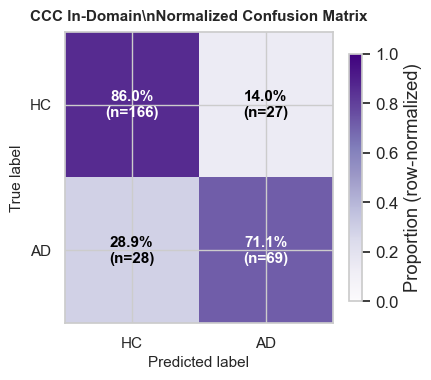

Saved: /Users/gloria/Documents/uniproject/thesis/visualizations/in_domain_feature_stability_visualizations/ccc_in_domain_confusion_matrix.png
Saved: ccc_in_domain_confusion_matrix.csv


In [12]:
_title  = 'CCC In-Domain\\nNormalized Confusion Matrix'
_saveto = os.path.join(VIZ_DIR, 'ccc_in_domain_confusion_matrix.png')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(ccc_cm_norm, cmap='Purples', vmin=0, vmax=1, aspect='auto')
for _i in range(2):
    for _j in range(2):
        _pct   = ccc_cm_norm[_i, _j] * 100
        _count = ccc_cm_raw[_i, _j]
        _col   = 'white' if ccc_cm_norm[_i, _j] > 0.55 else 'black'
        ax.text(_j, _i, f'{_pct:.1f}%\n(n={_count})',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color=_col)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['HC', 'AD'], fontsize=11)
ax.set_yticklabels(['HC', 'AD'], fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title(_title, fontsize=11, fontweight='bold', pad=8)
plt.colorbar(im, ax=ax, label='Proportion (row-normalized)', shrink=0.85)
plt.tight_layout()
plt.savefig(_saveto, dpi=150)
plt.show()
print(f'Saved: {_saveto}')

# Save CSV
_rows = []
for _ti, _tl in enumerate(['HC', 'AD']):
    for _pi, _pl in enumerate(['HC', 'AD']):
        _rows.append({'dataset': 'CCC', 'true_label': _tl,
                      'predicted_label': _pl,
                      'normalized_value': round(float(ccc_cm_norm[_ti, _pi]), 4),
                      'raw_count': int(ccc_cm_raw[_ti, _pi])})
pd.DataFrame(_rows).to_csv(
    os.path.join(OUTPUT_DIR, 'ccc_in_domain_confusion_matrix.csv'), index=False)
print('Saved: ccc_in_domain_confusion_matrix.csv')
